Вычисляем зависимость числа спайков и устойчивости...


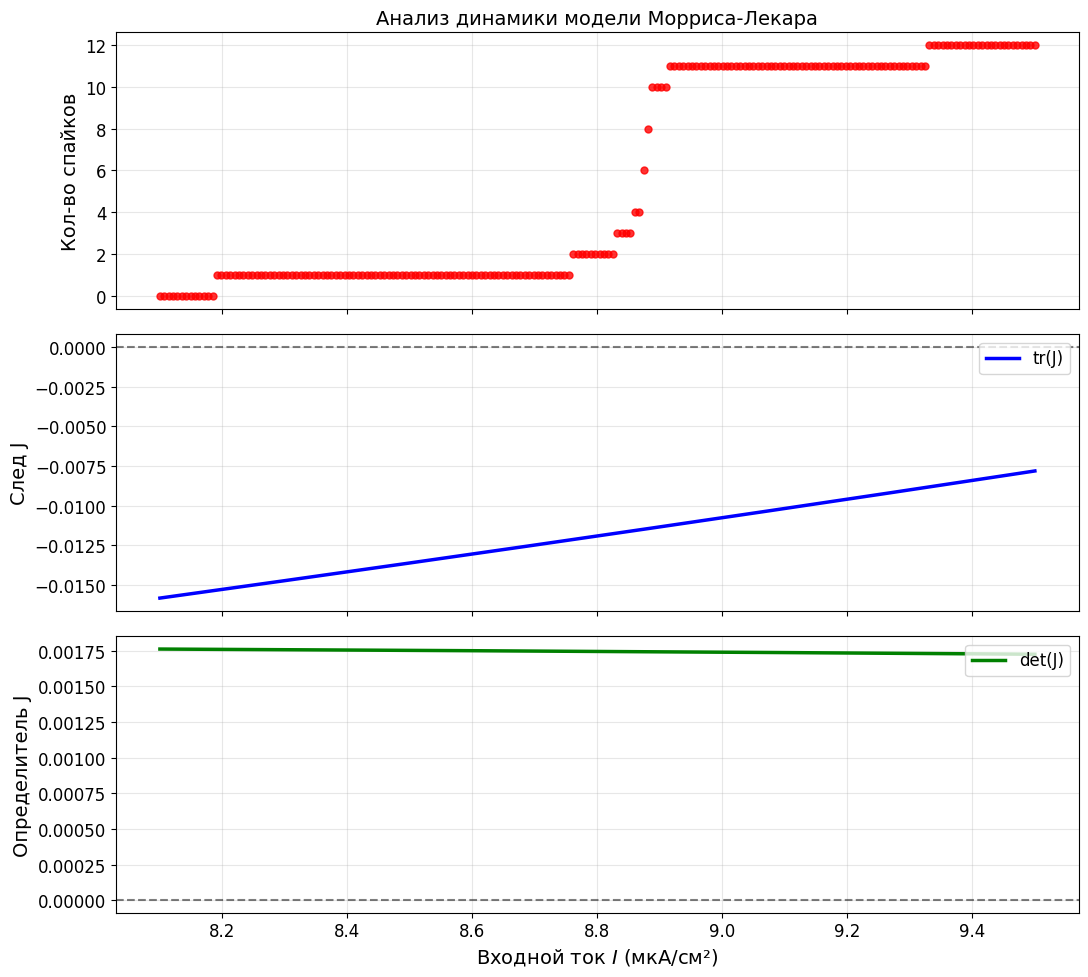

Генерация графиков V(t)...


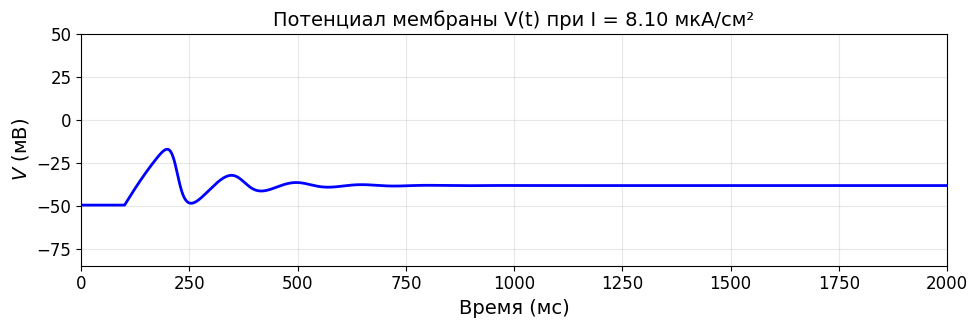

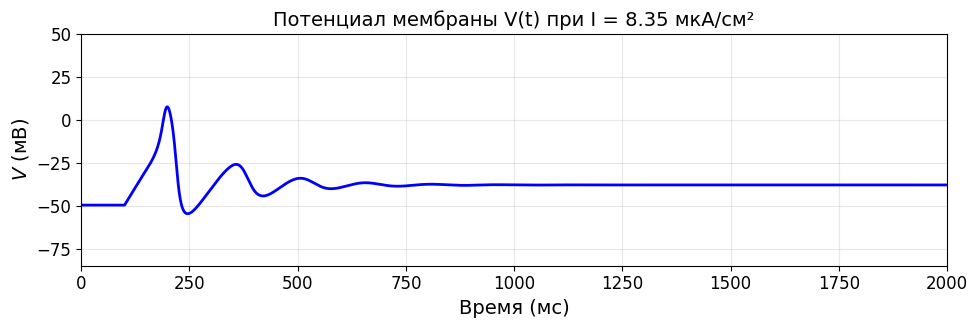

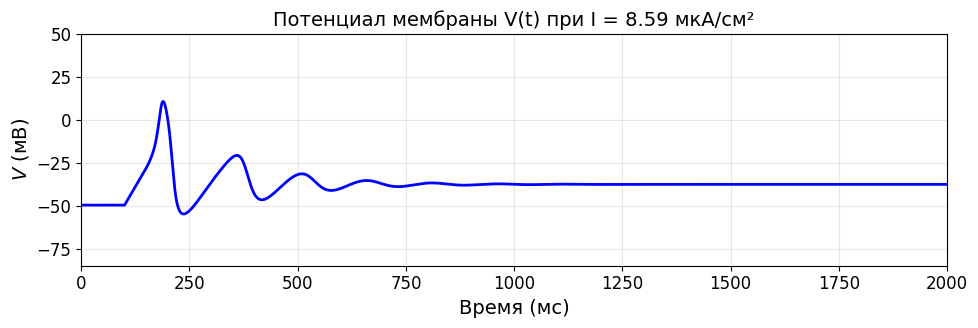

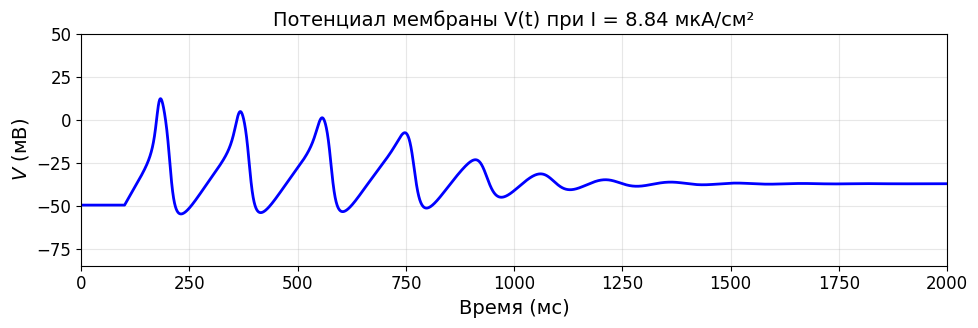

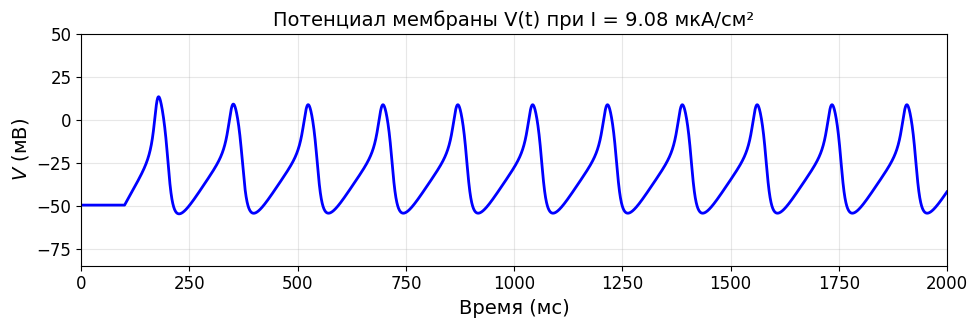

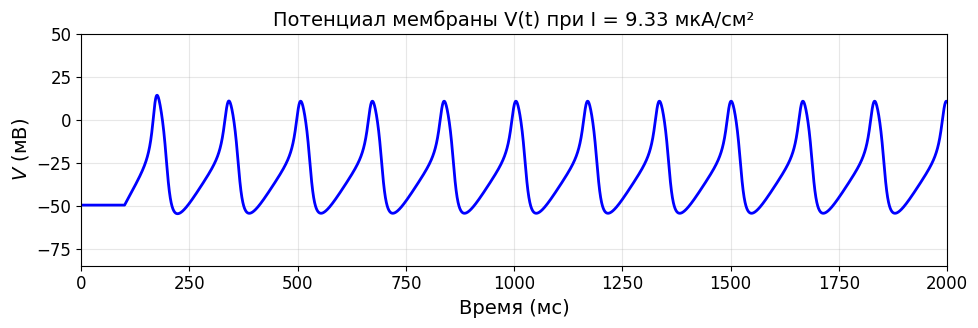

In [1]:
"""
Morris-Lecar Model: Spike Counting and Stability Analysis (Jacobian Trace/Det).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.signal import find_peaks

# Глобальная настройка шрифтов для качественных графиков
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

# Константы модели Морриса-Лекара
PARAMS = {
    'C': 20.0, 'g_leak': 0.20, 'V_leak': -50.0,
    'g_Ca': 4.4, 'V_Ca': 100.0, 'g_K': 8.0, 'V_K': -70.0,
    'V1': -1.0, 'V2': 15.0, 'V3': 2.0, 'V4': 30.0, 'phi': 0.05
}

def inf_m(V):
    return 1 / (1 + np.exp((PARAMS['V1'] - V) / PARAMS['V2']))

def inf_n(V):
    return 1 / (1 + np.exp((PARAMS['V3'] - V) / PARAMS['V4']))

def inf_Veq(V, I_hold):
    """Стационарное уравнение мембранных токов."""
    m_inf = inf_m(V)
    n_inf = inf_n(V)
    I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
    I_Ca = PARAMS['g_Ca'] * m_inf * (V - PARAMS['V_Ca'])
    I_K = PARAMS['g_K'] * n_inf * (V - PARAMS['V_K'])
    return (-I_leak - I_Ca - I_K + I_hold) / PARAMS['C']

def DBolt(V5, V, k):
    """Производная функции Больцмана."""
    return np.exp((V5 - V) / k) / (k * (1 + np.exp((V5 - V) / k))**2)

def trJ(V):
    """След матрицы Якобиана (trace)."""
    m_inf = inf_m(V)
    n_inf = inf_n(V)
    Dm_inf = DBolt(PARAMS['V1'], V, PARAMS['V2'])
    return -PARAMS['phi'] - (PARAMS['g_leak'] + PARAMS['g_K'] * n_inf +
             PARAMS['g_Ca'] * (m_inf + Dm_inf * (V - PARAMS['V_Ca']))) / PARAMS['C']

def detJ(V):
    """Определитель матрицы Якобиана (determinant)."""
    m_inf = inf_m(V)
    n_inf = inf_n(V)
    Dm_inf = DBolt(PARAMS['V1'], V, PARAMS['V2'])
    Dn_inf = DBolt(PARAMS['V3'], V, PARAMS['V4'])
    return (PARAMS['g_leak'] + PARAMS['g_K'] * (n_inf + Dn_inf * (V - PARAMS['V_K'])) +
            PARAMS['g_Ca'] * (m_inf + Dm_inf * (V - PARAMS['V_Ca']))) / PARAMS['C'] * PARAMS['phi']

def morris_lecar(t, y, I_func):
    """Правая часть системы ОДУ Морриса-Лекара."""
    V, n = y
    I = I_func(t)
    I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
    I_Ca = PARAMS['g_Ca'] * inf_m(V) * (V - PARAMS['V_Ca'])
    I_K = PARAMS['g_K'] * n * (V - PARAMS['V_K'])

    dVdt = (-I_leak - I_Ca - I_K + I) / PARAMS['C']
    dn_dt = PARAMS['phi'] * (inf_n(V) - n)
    return [dVdt, dn_dt]

def run_analysis():
    # Поиск потенциала покоя при I=0
    V0 = fsolve(lambda V: inf_Veq(V, 0.0), -60.0)[0]
    y0 = [V0, inf_n(V0)]

    I_currents = np.linspace(8.1, 9.5, 200)
    t_span = [0, 2000]
    t_eval = np.linspace(0, 2000, 10000)
    stim_period = t_eval > 100 # Считаем спайки только после начала стимуляции

    spike_counts = []
    trace_list = []
    det_list = []
    V_solutions = []

    print("Вычисляем зависимость числа спайков и устойчивости...")

    for I in I_currents:
        # Ступенчатый ток: подается со 100-й миллисекунды
        def input_I(t):
            return np.where(t < 100, 0.0, I)

        sol = solve_ivp(lambda t, y: morris_lecar(t, y, input_I),
                        t_span, y0, t_eval=t_eval, method='LSODA', rtol=1e-6)

        # Нахождение пиков
        peaks, _ = find_peaks(sol.y[0][stim_period], height=0, distance=50)
        spike_counts.append(len(peaks))
        V_solutions.append(sol)

        # Вычисление стационарного состояния для текущего тока I и его устойчивости
        V_eq = fsolve(inf_Veq, -20.0, args=(I,), xtol=1e-6)[0]
        trace_list.append(trJ(V_eq))
        det_list.append(detJ(V_eq))

    # --- ВИЗУАЛИЗАЦИЯ ОСНОВНЫХ ХАРАКТЕРИСТИК ---
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

    # 1. Зависимость количества спайков от тока
    ax1.plot(I_currents, spike_counts, 'ro', markersize=5, alpha=0.8)
    ax1.set_ylabel('Кол-во спайков')
    ax1.set_title('Анализ динамики модели Морриса-Лекара')
    ax1.grid(True, alpha=0.3)

    # 2. След матрицы Якобиана
    ax2.plot(I_currents, trace_list, 'b-', linewidth=2.5, label='tr(J)')
    ax2.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax2.set_ylabel('След J')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')

    # 3. Определитель матрицы Якобиана
    ax3.plot(I_currents, det_list, 'g-', linewidth=2.5, label='det(J)')
    ax3.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Входной ток $I$ (мкА/см²)')
    ax3.set_ylabel('Определитель J')
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # --- ПОСТРОЕНИЕ ТРАЕКТОРИЙ V(t) ---
    print("Генерация графиков V(t)...")
    step = 35 # Шаг для отображения подмножества графиков потенциала
    for i in range(0, len(I_currents), step):
        sol = V_solutions[i]
        plt.figure(figsize=(10, 3.5))
        plt.plot(sol.t, sol.y[0], 'b-', linewidth=2)
        plt.title(f'Потенциал мембраны V(t) при I = {I_currents[i]:.2f} мкА/см²')
        plt.xlabel('Время (мс)')
        plt.ylabel('$V$ (мВ)')
        plt.xlim(t_span)
        plt.ylim(-85, 50)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    run_analysis()